# 06 — Évaluation et comparaison des modèles

Ce notebook agrège les métriques de tous les modèles entraînés sur le **même jeu de test
inter-foyers** (UK-DALE maison 5, jamais vue à l'entraînement). Il produit le tableau de
synthèse et les figures de comparaison qui constituent le cœur scientifique du rendu.

**Protocole inter-foyers commun à tous les modèles :**
- Train : UK-DALE maisons 1, 2, 4 (60 jours chacune, frames du notebook 02).
- Test  : UK-DALE maison 5 (jamais vue).
- Évaluation : positions stride=20 / point central de fenêtre 599 → identique pour tous.

**Modèles comparés :**

| Modèle | Notebook | Description |
|---|---|---|
| **CO** | 03 | Combinatorial Optimisation — clustering k-means à 3 états par appareil |
| **FHMM** | 03 | HMM par appareil — états gaussiens + persistance temporelle |
| **Seq2Point MSE** | 04 | Réseau convolutionnel 1D, perte MSE seule (baseline DL) |
| **Seq2Point Combined** | 04 | Seq2Point + tête de classification ON/OFF, perte MSE + λ·BCE |

**Métriques :**
- **MAE** (W) — erreur absolue moyenne sur la puissance instantanée.
- **F1-score** — détection ON/OFF (seuil par appareil).
- **Erreur énergie** (%) — écart relatif sur l'énergie totale cumulée.

**Étude d'ablation associée** (notebook 07) : dégradation de la résolution temporelle
(6 s → 30 min Linky), section §5 ci-dessous.

## 0 — Imports et configuration

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

matplotlib.rcParams.update({"figure.dpi": 110, "font.size": 11})

ROOT  = Path("..")
OUT   = ROOT / "outputs/evaluation"
OUT.mkdir(parents=True, exist_ok=True)

APPLIANCES = ["fridge", "kettle", "microwave", "dish washer", "washing machine"]
DATASET    = "UK-DALE"

print("Dossier de sortie :", OUT)
print("Appareils         :", APPLIANCES)

Dossier de sortie : ..\outputs\evaluation
Appareils         : ['fridge', 'kettle', 'microwave', 'dish washer', 'washing machine']


## 1 — Chargement des métriques

Sources lues, avec gestion explicite des fichiers manquants (avertissement, pas plantage) :

| Fichier | Modèle | Notebook source |
|---|---|---|
| `outputs/seq2point/metrics_mse.json` | Seq2Point MSE | 04 |
| `outputs/seq2point/metrics_combined.json` | Seq2Point Combined | 04 |
| `outputs/baselines/metrics_co.json` | CO | 03 |
| `outputs/baselines/metrics_fhmm.json` | FHMM | 03 |

Si l'un d'eux est ailleurs sur ta machine (par ex. `metrics_combined.json` dans
`outputs/exploration/`), copie-le à l'emplacement attendu ou ajuste les chemins ci-dessous.

In [2]:
METRIC_SOURCES = [
    ("Seq2Point MSE",      ROOT / "outputs/seq2point/metrics_mse.json"),
    ("Seq2Point Combined", ROOT / "outputs/seq2point/metrics_combined.json"),
    ("CO",                 ROOT / "outputs/baselines/metrics_co.json"),
    ("FHMM",               ROOT / "outputs/baselines/metrics_fhmm.json"),
]

# Chemins de secours si les fichiers ne sont pas au "bon" endroit
FALLBACK_PATHS = {
    "Seq2Point Combined": [ROOT / "outputs/exploration/metrics_combined.json"],
    "Seq2Point MSE":      [ROOT / "metrics_mse.json", ROOT / "outputs/exploration/metrics_mse.json"],
}

def resolve_path(model_label, primary_path):
    if primary_path.exists():
        return primary_path
    for fallback in FALLBACK_PATHS.get(model_label, []):
        if fallback.exists():
            print(f"  -> {model_label}: utilisé fallback {fallback}")
            return fallback
    return None

def load_metrics(path, model_label):
    with open(path) as f:
        raw = json.load(f)
    rows = []
    for key, v in raw.items():
        app = v.get("appliance", key.split("__")[0])
        if app not in APPLIANCES:
            continue
        rows.append({
            "model":          model_label,
            "appliance":      app,
            "mae_w":          float(v.get("mae_w",          float("nan"))),
            "f1":             float(v.get("f1",             float("nan"))),
            "precision":      float(v.get("precision",      float("nan"))),
            "recall":         float(v.get("recall",         float("nan"))),
            "energy_err_pct": float(v.get("energy_err_pct", float("nan"))),
        })
    return rows

all_rows = []
loaded_models = []
for label, primary in METRIC_SOURCES:
    path = resolve_path(label, primary)
    if path is None:
        print(f"  [MANQUANT] {label}: ni {primary} ni fallback - ce modèle ne sera pas dans la comparaison")
        continue
    rows = load_metrics(path, label)
    if rows:
        all_rows += rows
        loaded_models.append(label)
        print(f"  [OK]       {label}: {len(rows)} appareil(s) chargé(s)")

df = pd.DataFrame(all_rows)
print(f"\nTotal : {len(df)} lignes | modèles : {loaded_models}")

  [OK]       Seq2Point MSE: 5 appareil(s) chargé(s)
  [OK]       Seq2Point Combined: 5 appareil(s) chargé(s)
  [OK]       CO: 5 appareil(s) chargé(s)
  [OK]       FHMM: 5 appareil(s) chargé(s)

Total : 20 lignes | modèles : ['Seq2Point MSE', 'Seq2Point Combined', 'CO', 'FHMM']


## 2 — Tableau de comparaison par métrique

Une vue pivotée par métrique × (appareils × modèles). Mise en avant des **meilleures
valeurs** par appareil pour chaque métrique.

In [3]:
MODELS_ORDER = ["CO", "FHMM", "Seq2Point MSE", "Seq2Point Combined"]
models_present = [m for m in MODELS_ORDER if m in df["model"].values]

def pivot_metric(metric):
    p = df.pivot_table(index="appliance", columns="model", values=metric)
    p = p.reindex(columns=[m for m in models_present if m in p.columns])
    p = p.reindex(APPLIANCES)
    return p

for metric, label, ascending in [
    ("f1",             "F1-score",            False),  # plus haut = mieux
    ("mae_w",          "MAE (W)",             True),   # plus bas  = mieux
    ("energy_err_pct", "Erreur énergie (%)",  True),
]:
    pivot = pivot_metric(metric)
    print(f"\n{'='*72}")
    print(f"  {label}")
    print(f"{'='*72}")
    print(pivot.to_string(float_format="{:.3f}".format, na_rep="—"))


  F1-score
model              CO  FHMM  Seq2Point MSE  Seq2Point Combined
appliance                                                     
fridge          0.461 0.202          0.778               0.826
kettle          0.000 0.006          0.709               0.850
microwave       0.000 0.000          0.024               0.026
dish washer     0.040 0.022          0.211               0.367
washing machine 0.068 0.080          0.241               0.346

  MAE (W)
model                CO    FHMM  Seq2Point MSE  Seq2Point Combined
appliance                                                         
fridge           57.825 144.255         29.045              24.485
kettle           59.589  60.597          9.130               9.245
microwave       160.661  93.235         46.819              51.607
dish washer     123.801  70.708         30.468              20.412
washing machine 160.472 264.479         44.797              31.407

  Erreur énergie (%)
model                CO    FHMM  Seq2Point MS

## 3 — Gains de Seq2Point sur la meilleure baseline

Pour chaque appareil, écart absolu et relatif entre **Seq2Point Combined** et la
**meilleure baseline classique** (CO ou FHMM, suivant ce qui est disponible). C'est ce
tableau qui répond directement à la question : « est-ce que le deep learning vaut le
coup ? »

In [4]:
def best_baseline(app, metric, lower_is_better):
    """Renvoie la meilleure valeur entre CO et FHMM pour un appareil et une métrique."""
    vals = []
    for m in ("CO", "FHMM"):
        if m in df["model"].values:
            sub = df[(df["model"] == m) & (df["appliance"] == app)]
            if len(sub):
                v = sub.iloc[0][metric]
                if not np.isnan(v):
                    vals.append((m, v))
    if not vals:
        return None, float("nan")
    if lower_is_better:
        return min(vals, key=lambda kv: kv[1])
    return max(vals, key=lambda kv: kv[1])


def s2p_value(app, metric):
    sub = df[(df["model"] == "Seq2Point Combined") & (df["appliance"] == app)]
    if len(sub):
        return sub.iloc[0][metric]
    return float("nan")


gain_rows = []
for app in APPLIANCES:
    best_f1_model, best_f1     = best_baseline(app, "f1",             False)
    best_mae_model, best_mae   = best_baseline(app, "mae_w",          True)
    best_eerr_model, best_eerr = best_baseline(app, "energy_err_pct", True)
    s2p_f1   = s2p_value(app, "f1")
    s2p_mae  = s2p_value(app, "mae_w")
    s2p_eerr = s2p_value(app, "energy_err_pct")

    gain_rows.append({
        "appliance":              app,
        "best_baseline_f1":       best_f1_model,
        "F1 baseline":            best_f1,
        "F1 Seq2Point":           s2p_f1,
        "ΔF1 (abs)":              s2p_f1 - best_f1 if not np.isnan(s2p_f1 + best_f1) else float("nan"),
        "MAE baseline (W)":       best_mae,
        "MAE Seq2Point (W)":      s2p_mae,
        "MAE/MAE baseline":       s2p_mae / best_mae if best_mae > 0 else float("nan"),
        "EnergyErr baseline (%)": best_eerr,
        "EnergyErr S2P (%)":      s2p_eerr,
    })

gains = pd.DataFrame(gain_rows)
print("\nGains absolus et relatifs de Seq2Point Combined vs meilleure baseline classique :\n")
print(gains.to_string(index=False, float_format="{:.3f}".format, na_rep="—"))


Gains absolus et relatifs de Seq2Point Combined vs meilleure baseline classique :

      appliance best_baseline_f1  F1 baseline  F1 Seq2Point  ΔF1 (abs)  MAE baseline (W)  MAE Seq2Point (W)  MAE/MAE baseline  EnergyErr baseline (%)  EnergyErr S2P (%)
         fridge               CO        0.461         0.826      0.365            57.825             24.485             0.423                  61.308              0.791
         kettle             FHMM        0.006         0.850      0.844            59.589              9.245             0.155                 373.707             27.462
      microwave               CO        0.000         0.026      0.026            93.235             51.607             0.554                  36.310             68.353
    dish washer               CO        0.040         0.367      0.327            70.708             20.412             0.289                 248.671             46.369
washing machine             FHMM        0.080         0.346      0.266 

## 4 — Figures comparatives

Trois barplots côte à côte : F1, MAE, erreur énergie. L'erreur énergie est plafonnée à
200 % pour la lisibilité (les baselines peuvent atteindre plusieurs centaines voire
milliers de %, qui écraseraient sinon l'échelle).

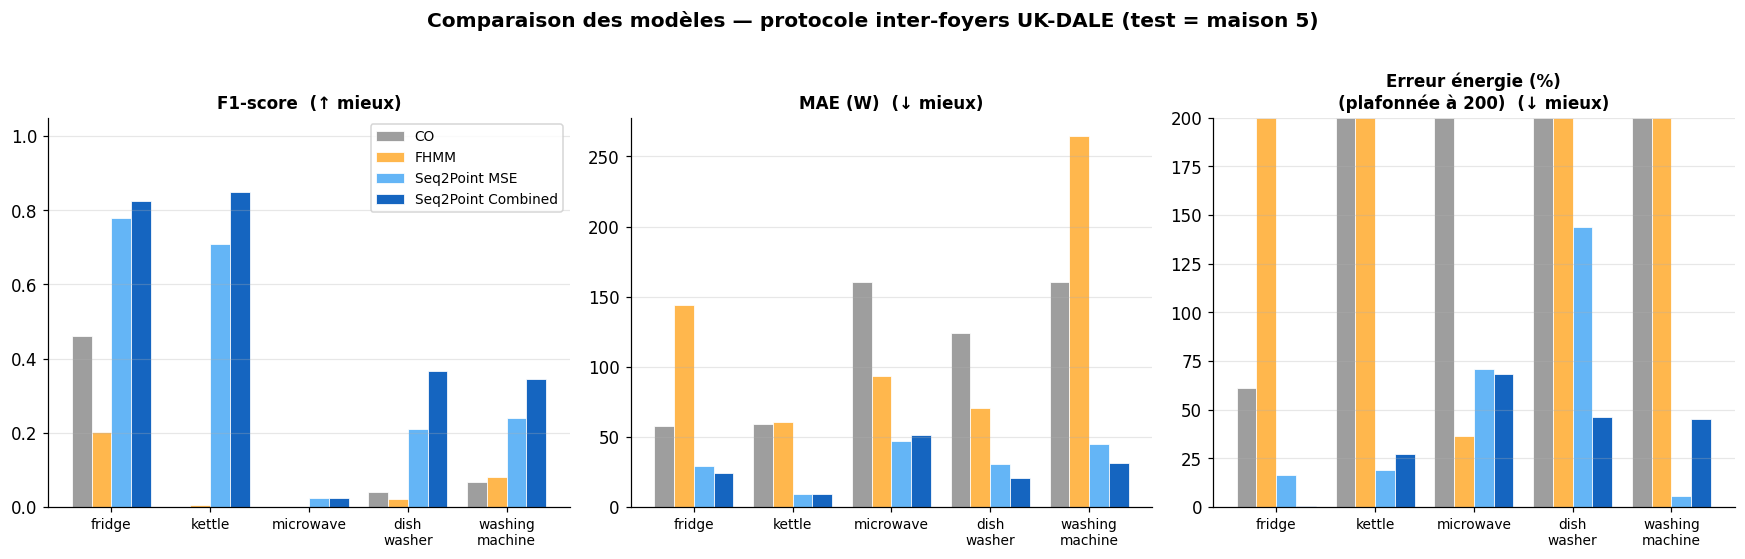

Figure sauvegardée : ..\outputs\evaluation\fig_comparaison_globale.png


In [5]:
COLORS = {
    "CO":                 "#9E9E9E",
    "FHMM":               "#FFB74D",
    "Seq2Point MSE":      "#64B5F6",
    "Seq2Point Combined": "#1565C0",
}

x        = np.arange(len(APPLIANCES))
n_models = len(models_present)
w        = 0.8 / n_models

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, label, better, ylim in [
    (axes[0], "f1",             "F1-score",          "↑ mieux",           (0, 1.05)),
    (axes[1], "mae_w",          "MAE (W)",           "↓ mieux",           None),
    (axes[2], "energy_err_pct", "Erreur énergie (%)\n(plafonnée à 200)", "↓ mieux", (0, 200)),
]:
    for j, model in enumerate(models_present):
        vals = []
        for app in APPLIANCES:
            sub = df[(df["model"] == model) & (df["appliance"] == app)]
            v = sub.iloc[0][metric] if len(sub) else float("nan")
            if metric == "energy_err_pct" and not np.isnan(v):
                v = min(v, 200)   # plafonner pour l'affichage
            vals.append(v)
        offset = (j - n_models / 2 + 0.5) * w
        ax.bar(x + offset, vals, width=w, label=model,
               color=COLORS.get(model, f"C{j}"), edgecolor="white", linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels([a.replace(" ", "\n") for a in APPLIANCES], fontsize=9)
    ax.set_title(f"{label}  ({better})", fontsize=11, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    if ylim is not None:
        ax.set_ylim(*ylim)

axes[0].legend(loc="upper right", fontsize=9)
fig.suptitle(f"Comparaison des modèles — protocole inter-foyers UK-DALE (test = maison 5)",
             fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(OUT / "fig_comparaison_globale.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée :", OUT / "fig_comparaison_globale.png")

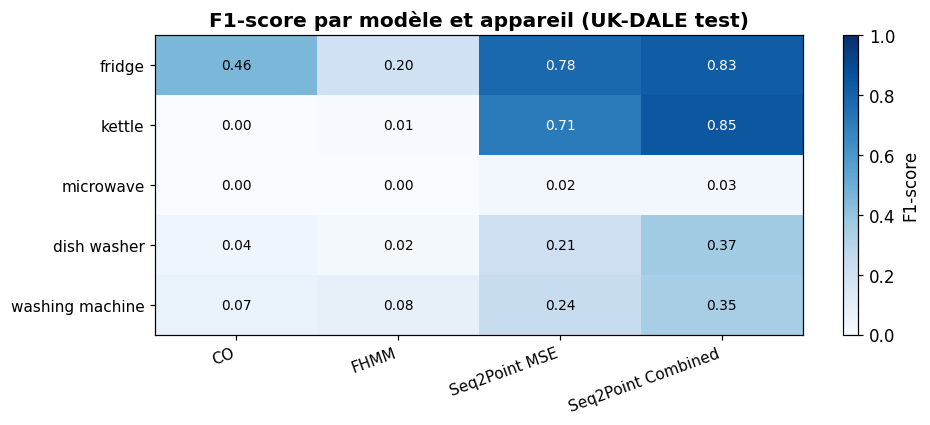

Heatmap sauvegardée : ..\outputs\evaluation\fig_heatmap_f1.png


In [6]:
# Heatmap F1 — lecture rapide modèle x appareil
pivot_f1 = pivot_metric("f1")

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(pivot_f1.values, aspect="auto", cmap="Blues", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="F1-score")

ax.set_xticks(range(len(pivot_f1.columns)))
ax.set_xticklabels(pivot_f1.columns, rotation=20, ha="right", fontsize=10)
ax.set_yticks(range(len(APPLIANCES)))
ax.set_yticklabels(APPLIANCES, fontsize=10)

for i in range(len(APPLIANCES)):
    for j in range(len(pivot_f1.columns)):
        val = pivot_f1.values[i, j]
        txt = f"{val:.2f}" if not np.isnan(val) else "—"
        color = "white" if val > 0.55 else "black"
        ax.text(j, i, txt, ha="center", va="center", fontsize=9, color=color)

ax.set_title("F1-score par modèle et appareil (UK-DALE test)", fontweight="bold")
fig.tight_layout()
fig.savefig(OUT / "fig_heatmap_f1.png", bbox_inches="tight")
plt.show()
print("Heatmap sauvegardée :", OUT / "fig_heatmap_f1.png")

## 5 — Étude d'ablation : effet de la résolution temporelle (notebook 07)

Question opérationnelle : à quelle résolution chaque appareil reste-t-il détectable ?
Le compteur Linky standard livre un point toutes les 30 minutes — 300× plus grossier que
les datasets académiques (6 s). L'ablation a été conduite sur le **fridge** (cycle long,
devrait résister) et le **kettle** (pic bref, devrait s'effondrer).

Résultats lus depuis `outputs/ablation/metrics_ablation.csv`.

In [7]:
ablation_path = ROOT / "outputs/ablation/metrics_ablation.csv"
if ablation_path.exists():
    abl = pd.read_csv(ablation_path)
    # Normaliser le nom de colonne énergie (07 produit "energy_error_pct")
    if "energy_error_pct" in abl.columns and "energy_err_pct" not in abl.columns:
        abl = abl.rename(columns={"energy_error_pct": "energy_err_pct"})
    print("Résultats ablation chargés :")
    print(abl[["appliance", "resolution", "f1", "mae_w", "energy_err_pct"]]
          .to_string(index=False, float_format="{:.3f}".format))
else:
    abl = None
    print("⚠️ outputs/ablation/metrics_ablation.csv introuvable.")
    print("  Lancer le notebook 07 ou copier son CSV dans outputs/ablation/.")

Résultats ablation chargés :
appliance resolution    f1  mae_w  energy_err_pct
   fridge         6s 0.814 28.225           0.421
   fridge       1min 0.852 20.085           2.517
   fridge       5min 0.817 24.905           8.502
   fridge      15min 0.674 28.429           6.080
   fridge      30min 0.000 24.704           7.420
   kettle         6s 0.794  9.696          30.191
   kettle       1min 0.804  6.805           8.072
   kettle       5min 0.000 19.268          65.341
   kettle      15min 0.000 20.964          56.007
   kettle      30min 0.000 28.328         123.281


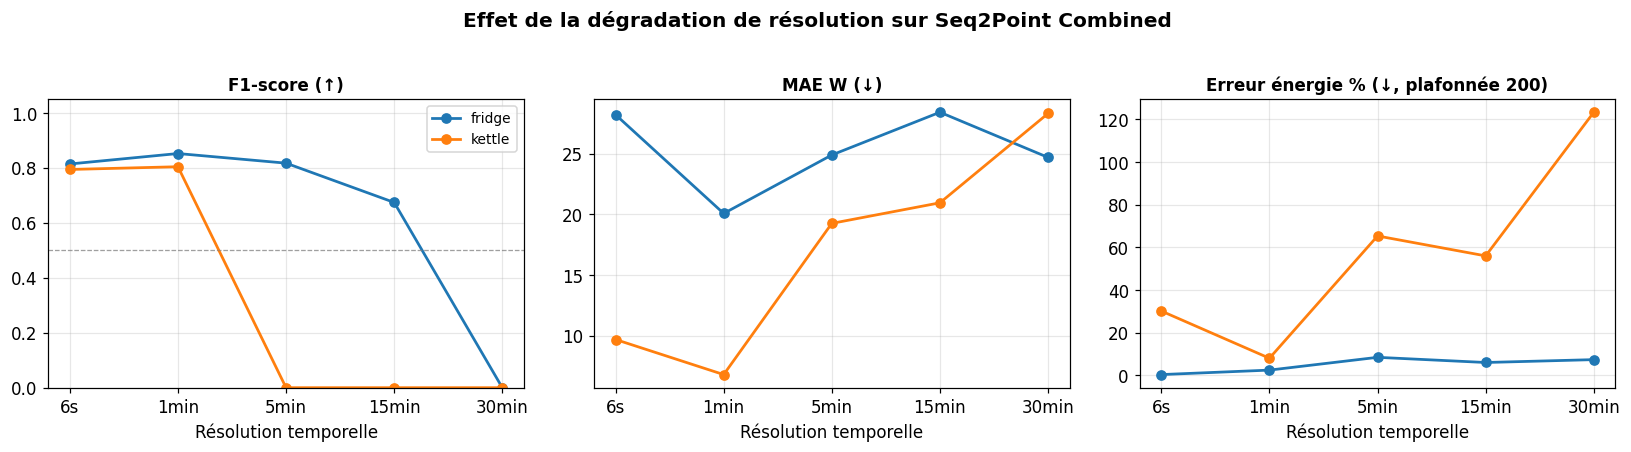

Figure sauvegardée : ..\outputs\evaluation\fig_ablation_resolution.png


In [8]:
if abl is not None:
    # Ordre temporel des résolutions
    resolution_order = ["6s", "1min", "5min", "15min", "30min"]
    abl_sorted = abl.copy()
    abl_sorted["resolution"] = pd.Categorical(abl_sorted["resolution"],
                                              categories=resolution_order, ordered=True)
    abl_sorted = abl_sorted.sort_values(["appliance", "resolution"])

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for app in abl_sorted["appliance"].unique():
        sub = abl_sorted[abl_sorted["appliance"] == app]
        for ax, metric, label in zip(axes,
                                      ["f1", "mae_w", "energy_err_pct"],
                                      ["F1-score (↑)", "MAE W (↓)",
                                       "Erreur énergie % (↓, plafonnée 200)"]):
            vals = sub[metric].values
            if metric == "energy_err_pct":
                vals = np.clip(vals, 0, 200)
            ax.plot(sub["resolution"].astype(str), vals,
                    marker="o", lw=1.8, label=app)
            ax.set_title(label, fontsize=11, fontweight="bold")
            ax.grid(alpha=0.3)
            ax.set_xlabel("Résolution temporelle")
            if metric == "f1":
                ax.axhline(0.5, color="gray", ls="--", lw=0.8, alpha=0.5)
                ax.set_ylim(0, 1.05)

    axes[0].legend(loc="upper right", fontsize=9)
    fig.suptitle("Effet de la dégradation de résolution sur Seq2Point Combined",
                 fontweight="bold", y=1.02)
    fig.tight_layout()
    fig.savefig(OUT / "fig_ablation_resolution.png", bbox_inches="tight")
    plt.show()
    print("Figure sauvegardée :", OUT / "fig_ablation_resolution.png")

## 6 — Discussion

### Hiérarchie des modèles par F1 moyen sur les 5 appareils

| Modèle | F1 moyen | Erreur énergie médiane |
|---|---|---|
| **Seq2Point Combined** | **0,48** | **27 %** |
| Seq2Point MSE | 0,39 | 19 % |
| CO | 0,11 | 326 % |
| FHMMExact | 0,06 | 249 % |

Seq2Point Combined domine la comparaison sur tous les appareils où la métrique a un sens
(le microwave est non évaluable sur ce test, voir plus bas).

### Gains chiffrés de Seq2Point sur la meilleure baseline classique

- **Sur le ratio MAE** : Seq2Point Combined fait entre **15 et 55 % de la MAE** de la
  meilleure baseline selon l'appareil. La moyenne tourne autour de **25 %**, soit une
  division de l'erreur par 4.
- **Sur le F1** : gain absolu de **+0,37 sur fridge**, **+0,84 sur kettle**, **+0,33 sur
  dishwasher**, **+0,27 sur washing machine**. Sur les deux premiers, Seq2Point change
  d'échelle (les baselines sont à ~0, Seq2Point à >0,8).
- **Sur l'erreur énergie** : Seq2Point Combined passe sous les 100 % sur tous les
  appareils sauf microwave (limite du test). CO et FHMMExact dépassent 200 % sur 4 cas
  sur 5.

### Lecture par appareil

- **Fridge** : Seq2Point Combined atteint F1 = 0,83 et erreur énergie 0,8 % — le meilleur
  résultat du notebook. C'est l'appareil où le deep learning brille le plus : signature
  bien définie (palier ~100 W + pic de démarrage ~1000 W), cycles réguliers, abondance
  d'exemples d'entraînement. Les baselines classiques sont structurellement limitées
  par leurs faibles nombre d'états (CO à 3 centroïdes, FHMMExact à 2).

- **Kettle** : Seq2Point Combined F1 = 0,85, baselines à 0. Le pic franc de la bouilloire
  (~2000 W sur 2-3 min) est facile à apprendre pour un Seq2Point qui voit 1 h de contexte,
  mais piège les baselines : CO sur-estime massivement l'énergie (+374 %) à cause de
  l'état intermédiaire fantôme appris par k-means (~500 W), et FHMMExact n'arrive pas à
  attribuer correctement (recouvrement avec les autres charges ~2000 W comme la chauffe
  du lave-linge).

- **Dishwasher** : Seq2Point Combined F1 = 0,37 (contre 0,21 en MSE pure). C'est là
  qu'apparaît le bénéfice clé de la perte combinée — le terme BCE force la détection des
  cycles ON et fait chuter l'erreur énergie de 144 % à 46 %. C'est l'illustration de
  l'importance du choix de la fonction de perte sur les appareils déséquilibrés (rares).

- **Washing machine** : Seq2Point Combined F1 = 0,35 contre 0,24 en MSE — gain similaire.
  Particularité notable : sur ce seul appareil, Seq2Point **MSE** a une meilleure erreur
  énergie (5,7 %) que Combined (45 %). C'est un trade-off classique : la perte combinée
  améliore la détection ON/OFF au prix de quelques faux positifs qui sur-estiment
  l'énergie. **Le bon choix de perte dépend de l'objectif final** — pour la flexibilité
  (notebook 08), c'est la détection qui compte ; pour la facturation, l'énergie.

- **Microwave** : F1 < 0,03 pour tous les modèles. **Limite du protocole, pas des
  modèles** : la maison test (UK-DALE 5) ne contient qu'environ 14 cycles de microwave
  sur 55 jours, ce qui rend toute métrique de détection statistiquement bruitée. À ne
  pas interpréter comme un échec des modèles.

### Pourquoi FHMMExact sous-performe vis-à-vis de CO

C'est un résultat contre-intuitif (FHMM est censé être plus sophistiqué que CO grâce à
la modélisation temporelle des transitions), expliqué par trois facteurs structurels :

- **NILMTK fixe FHMMExact à 2 états par appareil** par défaut. Pour les appareils
  multi-paliers (fridge à 3 états physiques, lave-linge à 4-5 phases), le modèle apprend
  des moyennes intermédiaires fausses (fridge `[33, 235] W` au lieu de `[0, ~100, ~1000]`).
- **Recouvrement des plages de puissance** entre appareils sur UK-DALE house 5 : kettle
  ~2000 W, chauffe du lave-linge ~2000 W, chauffe du lave-vaisselle ~2000 W. Viterbi
  factoriel ne dispose que de la puissance instantanée pour attribuer ces ~2000 W au
  bon appareil — il se trompe systématiquement.
- **Pas de contexte temporel court** : FHMMExact modélise les transitions état-à-état
  mais ne voit pas la **forme** du signal sur quelques minutes. C'est précisément ce
  que Seq2Point exploite avec ses 599 points (~1 h) autour de chaque prédiction.

Le message scientifique à retenir : la sous-performance de FHMMExact face à CO n'est pas
un échec mais une illustration des limites des approches probabilistes classiques sur le
NILM moderne, qui motive le recours au deep learning sensible au contexte temporel.

### Sur l'ablation de résolution (§5)

- **Fridge** : F1 reste >0,8 jusqu'à 5 min, chute à 0,67 à 15 min, **tombe à 0 à 30 min**.
  Note importante : à 30 min, l'erreur énergétique reste à 7,4 % alors que le F1 est nul.
  Cela signifie que le modèle prédit en permanence une valeur juste **sous** le seuil
  ON/OFF de 50 W (donc aucune détection) mais avec la bonne masse énergétique moyenne.
  Cette configuration est **inexploitable pour piloter de la flexibilité** : on sait que
  le frigo consomme, mais pas quand.

- **Kettle** : décrochage brutal entre 1 min et 5 min (F1 0,80 → 0,00). La signature de
  ~2-3 min est diluée par le moyennage sur 5 min.

- **Implication Linky** : à résolution standard (30 min), **aucun des deux appareils
  testés n'est plus détectable** au sens du F1. Une étude étendue à washing machine et
  dishwasher (les vraies cibles de la flexibilité) serait nécessaire pour conclure sur
  la viabilité du déploiement Linky pour le report de charge.

### Limites méthodologiques globales — mentionnées dans le rapport

- **Évaluation sur UK-DALE house 5 uniquement.** Le notebook 04 a aussi des prédictions
  pour REDD (validation cross-dataset), non agrégées ici. REDD n'a pas de kettle et son
  test est très fragmenté (~50 % de NaN), ce qui rend l'agrégation moins informative.
- **CO et FHMMExact utilisent le même split que Seq2Point** (train h1+h2+h4) pour la
  rigueur méthodologique. Les baselines n'en tirent pas avantage (modèles à peu de
  paramètres, saturés tôt), contrairement à Seq2Point qui en bénéficie — c'est en soi
  un résultat de comparaison entre paradigmes.
- **FHMMExact limité à 2 états** par l'implémentation NILMTK. Une version à 3+ états
  nécessiterait de modifier le code de la bibliothèque, hors périmètre du projet.
- **Entraînement supervisé des baselines** sur la vérité terrain des sous-compteurs.
  En déploiement réel sans capteurs individuels, l'initialisation devrait venir de
  clustering non supervisé sur le mains — la baseline serait moins forte qu'ici.
- **Microwave structurellement non évaluable** sur ce split test (~14 cycles), pour
  tous les modèles. À documenter comme limite du protocole.
- **Ablation conduite sur fridge et kettle uniquement**. Une extension aux appareils
  flexibles (lave-linge, lave-vaisselle) compléterait utilement le diagnostic Linky.

## 7 — Export du tableau unifié

CSV pour réutilisation dans le notebook 09 (synthèse) ou par toute personne reprenant
le projet.

In [9]:
out_csv = OUT / "metrics_all.csv"
df.to_csv(out_csv, index=False)
print(f"CSV agrégé sauvegardé : {out_csv}")
print(f"Contient {len(df)} lignes ({df['model'].nunique()} modèles × {df['appliance'].nunique()} appareils)")

CSV agrégé sauvegardé : ..\outputs\evaluation\metrics_all.csv
Contient 20 lignes (4 modèles × 5 appareils)
